In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
root_dir = os.path.abspath('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    fbeta_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder

train = pd.read_csv(os.path.join(root_dir, 'data/titanic/train.csv'))
train=train.drop("PassengerId",axis=1)
test = pd.read_csv(os.path.join(root_dir, 'data/titanic/test.csv'))
test = test.drop('PassengerId',axis=1)
y=train['Survived']


# Data Wrangler 
- Cabin имеет 77 % пропусков - удаляем, 20 % в Age: заменю средним; Embarked - 2 пропуска: 70 % встречается значение S-им заменю
- В целевой переменной погибших в 1.6 раз больше чем выживших. Несболонсированно 
- Больше всего 3 класса в Pclass 
- Мужчин больше женщин
- Сильный хвост у колонки Fare, делаю capping, затем логарифмирую со сдвигам. Проверю на метрики, может лучше будет удалить выбросы.
- Ticket - чересчур много уникальных значений- удалю
- Name - текст, из него надо извлечь титулы
- Pclass - ordinal category, содержит порядок, применю one-hot



/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 61.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Pclass  Sex     Survived
1       female  1           0.968085
                0           0.031915
        male    0           0.631148
                1           0.368852
2       female  1           0.921053
                0           0.078947
        male    0           0.842593
                1           0.157407
3       female  1           0.500000
                0           0.500000
        male    0           0.864553
                1           0.135447
Name: proportion, dtype: float64

/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 38.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 66.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


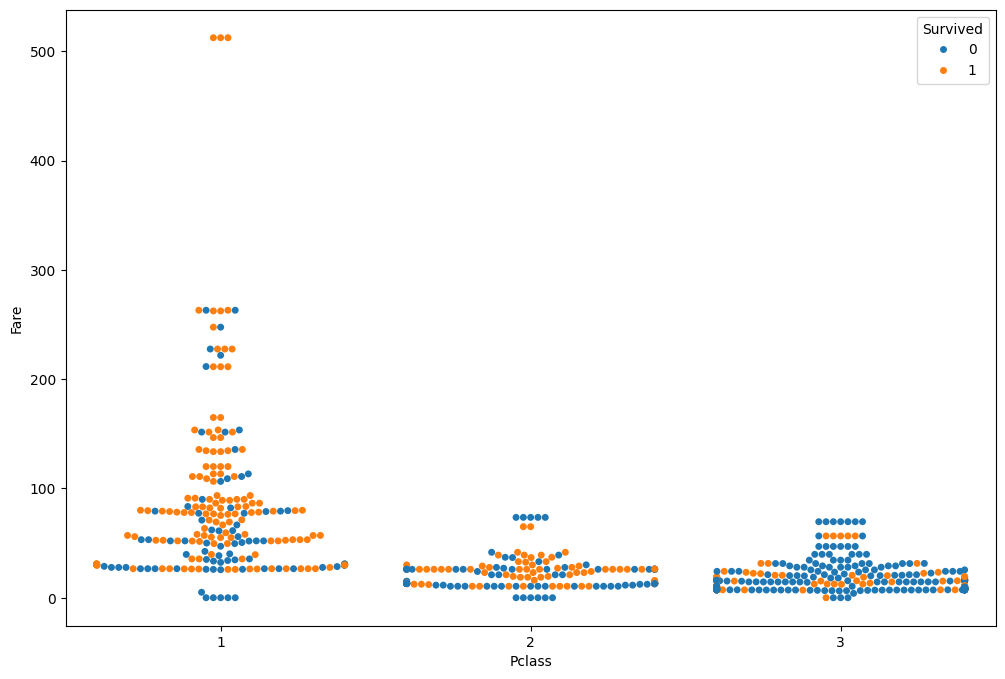

In [2]:
#влияние цены билета и класса
fig = plt.figure(figsize=(12,8))
sns.swarmplot(x="Pclass", y="Fare", data=train, hue="Survived")

#влияние класса и пола
train.groupby(['Pclass','Sex'])['Survived'].value_counts(normalize=True)



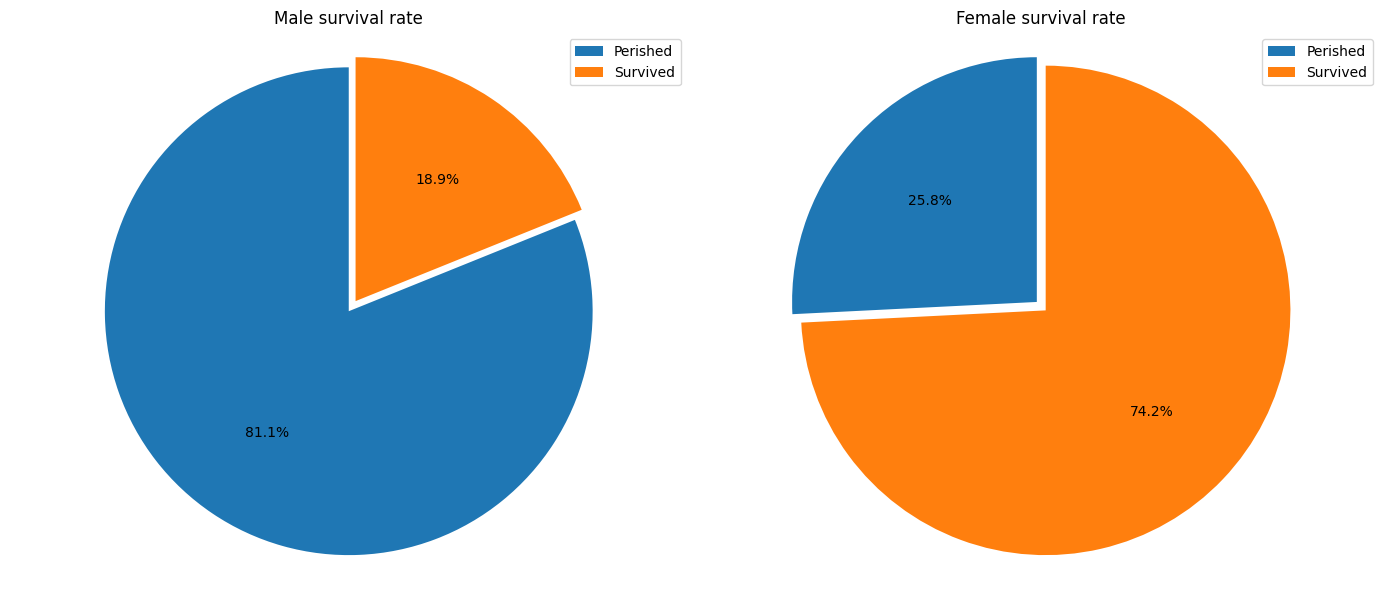

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Левый график (мужчины)
male_counts = train[train['Sex'] == 'male'].Survived.groupby(train.Survived).count()
ax1.pie(male_counts, 
        explode=[0, 0.05], 
        autopct='%1.1f%%', 
        startangle=90)
ax1.axis('equal')
ax1.set_title("Male survival rate")
ax1.legend(["Perished", "Survived"], loc='best')

# Правый график (женщины)
female_counts = train[train['Sex'] == 'female'].Survived.groupby(train.Survived).count()
ax2.pie(female_counts, 
        explode=[0, 0.05], 
        autopct='%1.1f%%', 
        startangle=90)
ax2.axis('equal')
ax2.set_title("Female survival rate")
ax2.legend(["Perished", "Survived"], loc='best')

plt.tight_layout()
plt.show()

In [4]:
women = train[train['Sex'] == 'female']
men = train[train['Sex'] == 'male']

women_survived = women[women['Survived'] == 1].shape[0]
women_total = women.shape[0]

men_died = men[men['Survived'] == 0].shape[0]
men_total = men.shape[0]

correct_predictions = women_survived + men_died
total_passengers = train.shape[0]

accuracy = correct_predictions / total_passengers * 100
print(f"Точность стратегии: {accuracy:.2f}%")

Точность стратегии: 78.68%


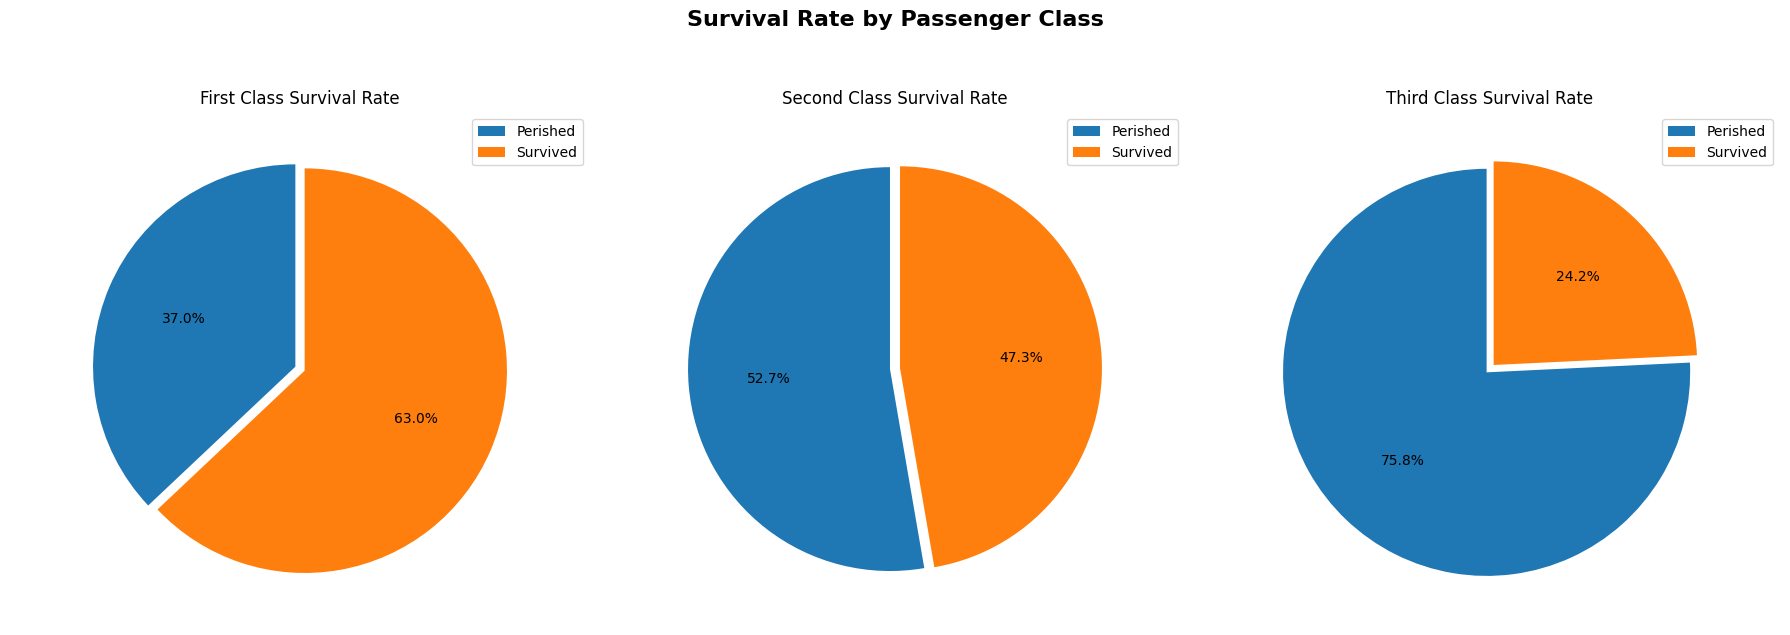

In [5]:

classes = {
    1: "First Class",
    2: "Second Class", 
    3: "Third Class"
}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))


for i, (pclass, title) in enumerate(classes.items()):
    data = train[train['Pclass'] == pclass].Survived.groupby(train.Survived).count()
    axes[i].pie(data, explode=[0, 0.05], autopct='%1.1f%%', startangle=90)
    axes[i].axis('equal')
    axes[i].set_title(f"{title} Survival Rate", fontsize=12)
    axes[i].legend(["Perished", "Survived"], loc='best')

fig.suptitle('Survival Rate by Passenger Class', fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

In [6]:
pd.crosstab([train.Sex, train.Survived], train.Pclass, margins=True)

Pclass             1    2    3  All
Sex    Survived                    
female 0           3    6   72   81
       1          91   70   72  233
male   0          77   91  300  468
       1          45   17   47  109
All              216  184  491  891

Женщины чаще выживали. Большая разница между выживаемость мужчин и женщин. Женщины из 1 и 2 классов выживали почти гарантированно. Женщины из 3 класса — лишь в половине случаев.Мужчины выживали плохо в любом классе, но в 1 классе шанс был заметно выше 37%.Во 2 и 3 классах шанс был минимален 14–16%
Признак Sex обязателен для модели. Признак Pclass даёт дополнительную информацию даже при наличии Sex.

In [7]:
pd.crosstab([train.Sex, train.Survived], [train.SibSp, train.Pclass], margins=True)

SibSp              0             1          2         3          4  5  8  All
Pclass             1    2    3   1   2   3  1  2   3  1  2   3   3  3  3     
Sex    Survived                                                              
female 0           1    3   33   2   3  21  0  0   3  0  0   7   4  1  3   81
       1          48   41   48  38  25  17  3  3   4  2  1   1   2  0  0  233
male   0          59   67  235  16  20  35  1  4   7  1  0   4  11  4  4  468
       1          29    9   35  15   7  10  1  1   1  0  0   0   1  0  0  109
All              137  120  351  71  55  83  5  8  15  3  1  12  18  5  7  891

У большинства пассажиров на борту не было родных братьев и сестер, а у большинства на борту был как минимум 1 родной брат.

В ходе спасательной операции пассажирам, у которых на борту были родные братья и сестры, не уделялось особого внимания

In [8]:
pd.crosstab([train.Sex, train.Survived], [train.Parch, train.Pclass], margins=True)

Parch              0             1           2          3     4     5  6  All
Pclass             1    2    3   1   2   3   1   2   3  2  3  1  3  3  3     
Sex    Survived                                                              
female 0           1    5   35   0   1  13   2   0  17  0  1  0  2  3  1   81
       1          63   40   50  17  17  12  11  11   8  2  1  0  0  1  0  233
male   0          63   81  260  10   7  22   3   3  15  0  1  1  1  1  0  468
       1          36    8   36   4   7   8   5   2   3  0  0  0  0  0  0  109
All              163  134  381  31  32  55  21  16  43  2  3  1  3  5  1  891

у большинства на борту было не более 1 родителя

В ходе спасательной операции пассажирам, у которых на борту были родители, не уделялось особого внимания

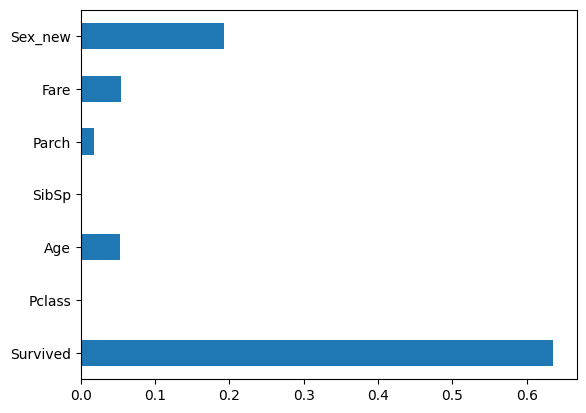

In [9]:
train_copy = train.copy()
train_copy['Sex_new'] = train_copy['Sex'].map({'male': 0, 'female': 1})

train_clean = train_copy.dropna()
train_clean = train_clean.select_dtypes(include=['number'])
y_clean = y[train_clean.index] 

importances = mutual_info_classif(train_clean, y_clean)
feature_importances = pd.Series(importances, index=train_clean.columns)
feature_importances.plot(kind='barh')
plt.show()

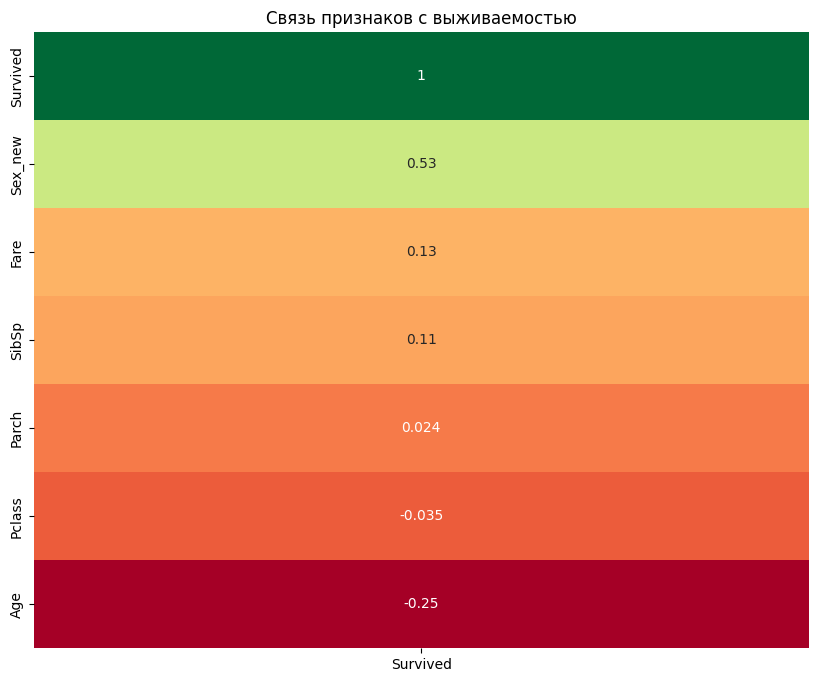

In [10]:

target_corr = train_clean.select_dtypes(include=['number']).corr()['Survived'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='RdYlGn', cbar=False)
plt.title('Связь признаков с выживаемостью')
plt.show()

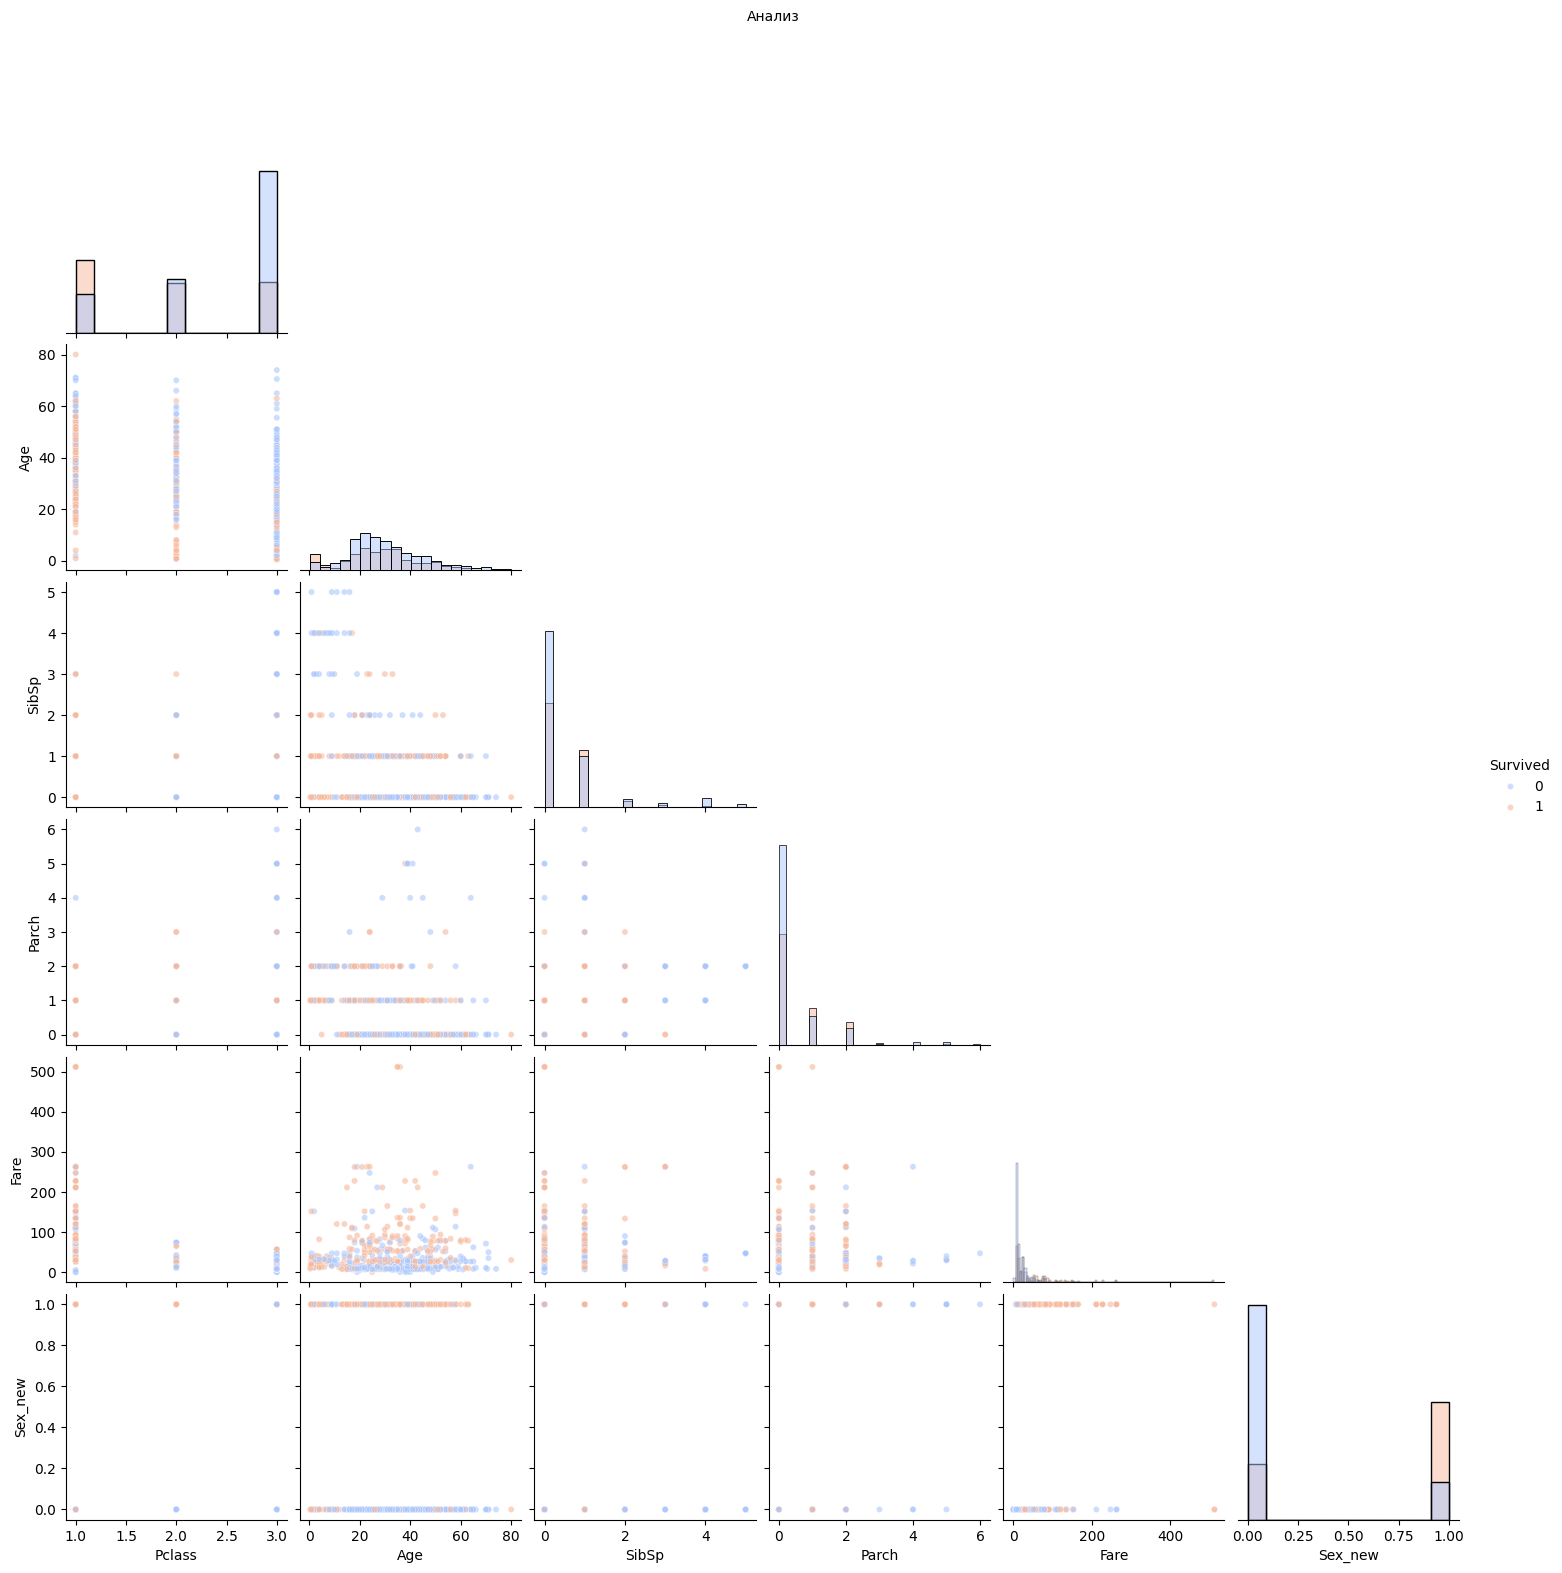

In [11]:
numeric_cols = train_copy.select_dtypes(include='number').columns.tolist()
plot_data = train_copy[numeric_cols].dropna()
sns.pairplot(plot_data, 
             hue='Survived',  # раскраска по целевой переменной
             palette='coolwarm',
             plot_kws={'alpha': 0.6, 's': 20},
             diag_kind='hist', 
             corner=True)    

plt.suptitle('Анализ',y=1.05, fontsize=10)
plt.show()


# Хорошие индикаторы
- У кого лучше класс, у тех больше была вероятность на выживание
- Дети с возрастом < 10 чаще выживали
- у кого дороже билет, те чаще выживали
- Небольшие семьи чаще выживали
- Женжины(в зависимости от класса) лучше выживали

SibSp — количество братьев/сестёр/супругов (у большинства 0-1)
Parch — количество родителей/детей (у большинства 0)

Можно объединить SibSp и Parch

Cabin удалю, Age средним, 
Embarked самым часто встречающимся значением



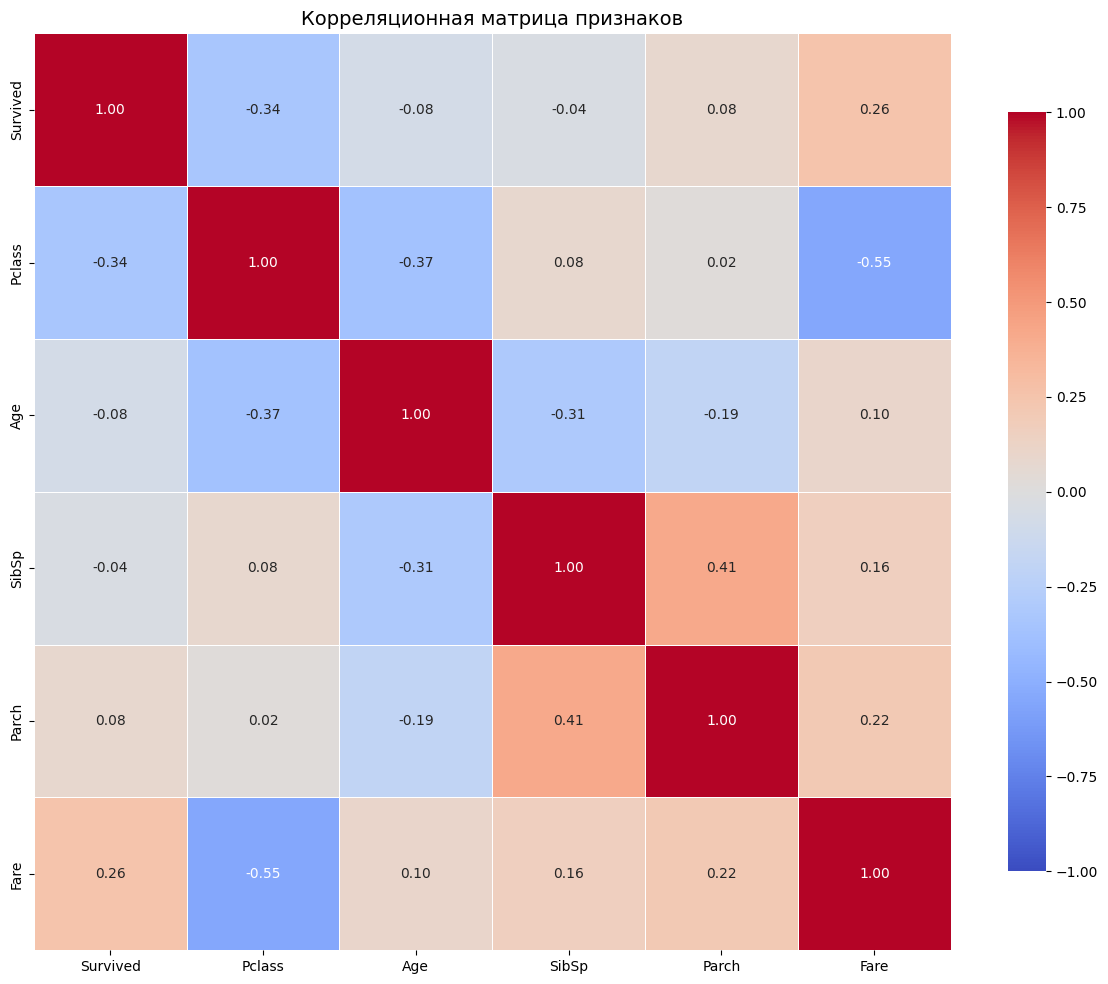

In [12]:
train_num=train.select_dtypes(include=['number'])
corr_matrix = train_num.corr()

# 2. Визуализируем через тепловую карту
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, 
            vmin=-1, vmax=1, 
            cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
#processing
train_copy = train.copy()
test_copy=test.copy()
train_copy['family'] = train_copy['SibSp']+train_copy['Parch']
"""train_copy['isAlone'] = (train_copy['family']==0).astype(int)"""
train_copy['Sex_new'] = train_copy['Sex'].map({'male': 0, 'female': 1})
train_copy = train_copy.drop(['SibSp', 'Parch', 'Cabin','Sex'], axis=1)
train_copy['Age']=train_copy['Age'].fillna(train_copy['Age'].mean(), inplace=True)
train_copy['Embarked']=train_copy['Embarked'].fillna('S',inplace=True)

"""train_copy['is_rich_woman'] = ((train_copy['Pclass'] == 1) & (train_copy['Sex_new'] == 1)).astype(int)"""
train_copy['child_first_class'] = ((train_copy['Age'] < 12) & (train_copy['Pclass'] == 1)).astype(int)

train_copy['Title'] = train_copy['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

main_titles = ['Mr', 'Miss', 'Mrs', 'Master']
train_copy.loc[~train_copy['Title'].isin(main_titles), 'Title'] = 'Rare'

train_copy = train_copy.drop(['Ticket','Name'],axis=1)

"""train_copy = pd.get_dummies(train_copy, columns=['Embarked'], prefix='Embarked', drop_first=True)
train_copy = pd.get_dummies(train_copy, columns=['Title'],   prefix='Title',   drop_first=True )"""

train_copy['Fare'] = train_copy['Fare'].clip(upper=train_copy['Fare'].quantile(0.99))
train_copy['Fare'] = np.log1p(train_copy['Fare'])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = ohe.fit_transform(train_copy[['Embarked', 'Title','Pclass']])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(['Embarked', 'Title','Pclass']),
    index=train_copy.index
)

train_copy = pd.concat([train_copy.drop(['Embarked', 'Title','Pclass'], axis=1), encoded_df], axis=1)
train_copy = train_copy.drop(columns=['Embarked_S', 'Pclass_3', 'Title_Mr'])

os.makedirs('../data_new', exist_ok=True)

train_copy.to_csv('../data_new/train_processed_titanic.csv', index=False)
"""test_copy.to_csv('../data_new/test_processed_titanic.csv', index=False)"""

/tmp/ipykernel_32658/2531686613.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_copy['Age']=train_copy['Age'].fillna(train_copy['Age'].mean(), inplace=True)
/tmp/ipykernel_32658/2531686613.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method

"test_copy.to_csv('../data_new/test_processed_titanic.csv', index=False)"

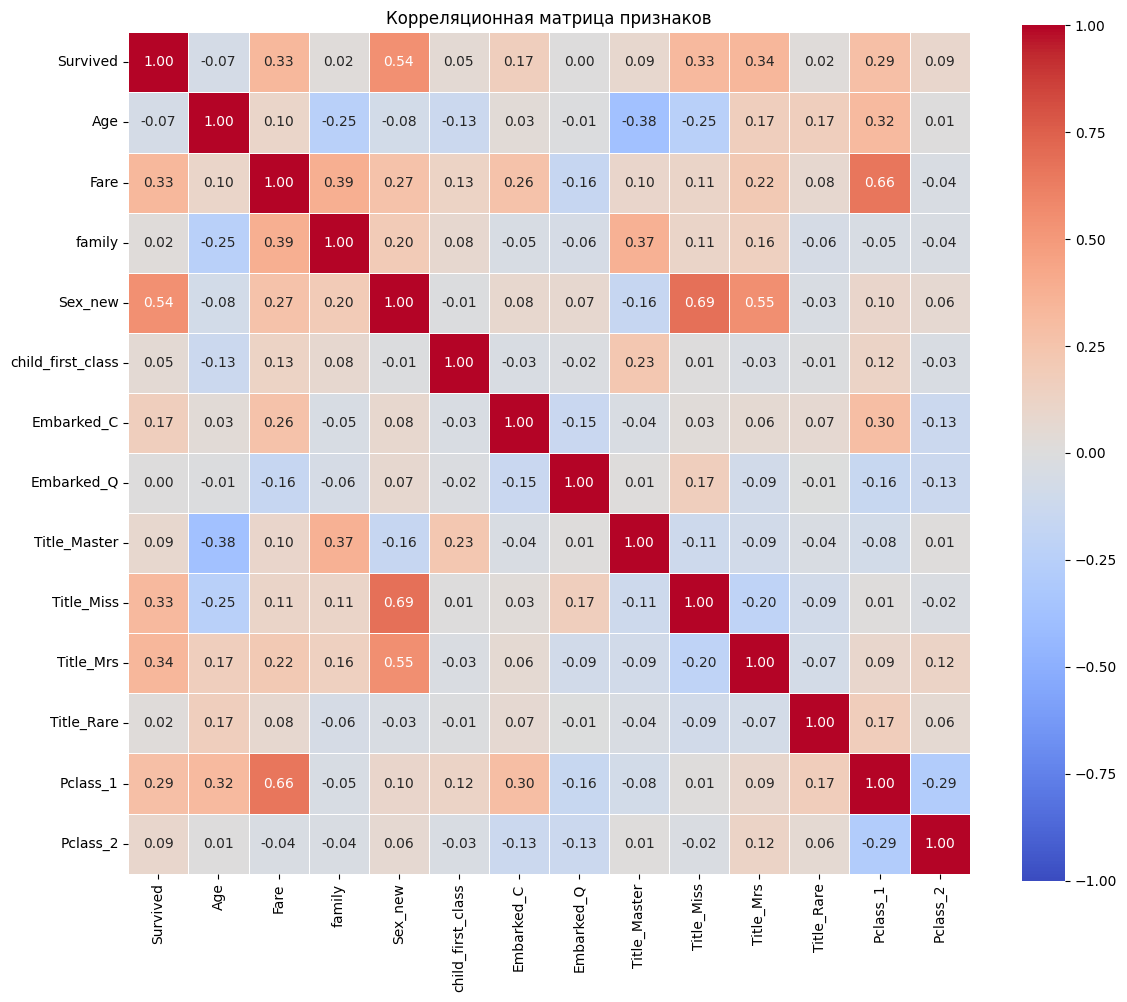

In [14]:
corr_matrix = train_copy.corr(method='pearson')

# Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

In [15]:

"""from statsmodels.stats.outliers_influence import variance_inflation_factor
X1 = train_copy.drop(columns=['Survived'])
vif_data = pd.DataFrame()
vif_data['feature'] = X1.columns
vif_data['VIF'] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))"""

"from statsmodels.stats.outliers_influence import variance_inflation_factor\nX1 = train_copy.drop(columns=['Survived'])\nvif_data = pd.DataFrame()\nvif_data['feature'] = X1.columns\nvif_data['VIF'] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]\nprint(vif_data.sort_values('VIF', ascending=False))"

In [16]:
#Pipline
X = train_copy.drop('Survived', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.8547
Precision: 0.8413
Recall   : 0.7681
F1-Score : 0.8030
ROC-AUC  : 0.8730


In [17]:
solvers = ['lbfgs', 'liblinear', 'saga']
results = {}

for svr in solvers:
    model_svr = LogisticRegression(random_state=42, max_iter=5000, solver=svr)
    model_svr.fit(X_train_scaled, y_train)
    
    y_pred_svr = model_svr.predict(X_test_scaled)
    y_prob_svr = model_svr.predict_proba(X_test_scaled)[:, 1]
    
    results[svr] = {
        'Accuracy': accuracy_score(y_test, y_pred_svr),
        'Precision': precision_score(y_test, y_pred_svr, pos_label=1),
        'Recall': recall_score(y_test, y_pred_svr, pos_label=1),
        'F1-Score': f1_score(y_test, y_pred_svr, pos_label=1),
        'ROC-AUC': roc_auc_score(y_test, y_prob_svr)
    }

df_compare = pd.DataFrame(results).T
print("Сравнение моделей по типам solver:")
display(df_compare.round(4))

Сравнение моделей по типам solver:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
lbfgs,0.8547,0.8413,0.7681,0.803,0.8730
liblinear,0.8492,0.8281,0.7681,0.797,0.8729
saga,0.8547,0.8413,0.7681,0.803,0.8729


In [22]:
threslholds = np.arange(0,1.01,0.01)
f1_scores = []
roc_scores = []
for th in threslholds:
    y_pred = (y_prob >= th).astype(int)
    f1_scores.append(f1_score(y_test,y_pred))
    roc_scores.append(roc_auc_score(y_test,y_pred))

bestf1 = threslholds[np.argmax(f1_scores)]
bestroc = threslholds[np.argmax(roc_scores)]

print(f'Оптимальный порог по F1 {bestf1}')
print(f'Максимальный по F1:{max(f1_scores)}')

print(f'Оптимальный порог по Roc-auc {bestroc}')
print(f'Максимальный по Roc-auc:{max(roc_scores)}')


Оптимальный порог по F1 0.5
Максимальный по F1:0.803030303030303
Оптимальный порог по Roc-auc 0.36
Максимальный по Roc-auc:0.8411725955204216


# 1 результат
Accuracy : 0.8436
Precision: 0.8154
Recall   : 0.7681
F1-Score : 0.7910
ROC-AUC  : 0.8743

Train Accuracy: 0.8272
Train ROC-AUC : 0.8791

# 2 результат - удаляю выбросы и создаю два новых признака зависимость выживаемости женщин и первого класса;зависмоть 1 класса и детей

Accuracy : 0.8492
Precision: 0.8281
Recall   : 0.7681
F1-Score : 0.7970
ROC-AUC  : 0.8717

Train Accuracy: 0.8272
Train ROC-AUC : 0.8785

# 3 результат - делаю преобразование one-hot для Pclass
Accuracy : 0.8492
Precision: 0.8281
Recall   : 0.7681
F1-Score : 0.7970
ROC-AUC  : 0.8739

# 4 результат - избавился от мультиколлинеарности некоторых признаков и 1 столбец в каждом признаке после one-hot. Удалил isalone,is_rich_woman
Accuracy : 0.8547
Precision: 0.8413
Recall   : 0.7681
F1-Score : 0.8030
ROC-AUC  : 0.8730 